# Task 1: Computer Vision Using CNN Models
## Part A: Traditional CNN Model


### 1. Import Libraries and Set Random Seed

Purpose:
Import required libraries and set a fixed random seed to ensure reproducibility of results.

In [ ]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# Fixed seed for reproducibility
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### 2. GPU Configuration Check

Purpose:
Verify that Google Colab has access to a GPU for faster model training.

In [ ]:
print("GPU Devices:")
print(tf.config.list_physical_devices('GPU'))

GPU Devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 3. Load CIFAR-10 Dataset

Purpose:
Load the CIFAR-10 dataset and inspect the dimensions of the training and testing sets.

In [ ]:
# Load CIFAR-10 dataset
from tensorflow.keras.datasets import cifar10

# Load training and testing data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Data Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Data Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Data Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Data Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


Observation:

The CIFAR-10 dataset was successfully loaded. It contains 50,000 training images and 10,000 testing images. Each image has dimensions of 32×32 pixels with 3 color channels (RGB), making it suitable for image classification tasks using Convolutional Neural Networks.

In [ ]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Create Folder in Google Drive

import os

save_path = "/content/drive/MyDrive/iNeuBytes_CIFAR10"

os.makedirs(save_path, exist_ok=True)

print("Folder Created Successfully!")
print("Folder Path:", save_path)

Folder Created Successfully!
Folder Path: /content/drive/MyDrive/iNeuBytes_CIFAR10


In [ ]:
#Save Datasets to Google Drive

import numpy as np

# Save Training Data
np.save(f"{save_path}/X_train.npy", X_train)
np.save(f"{save_path}/y_train.npy", y_train)

# Save Validation Data
np.save(f"{save_path}/X_val.npy", X_val)
np.save(f"{save_path}/y_val.npy", y_val)

# Save Testing Data
np.save(f"{save_path}/X_test.npy", X_test)
np.save(f"{save_path}/y_test.npy", y_test)

print("All Dataset Files Saved Successfully!")

All Dataset Files Saved Successfully!


In [ ]:
# Verify Saved Files

import os

files = os.listdir(save_path)

print("Files Found in Drive Folder:\n")

for file in files:
    print(file)

Files Found in Drive Folder:

X_train.npy
y_train.npy
X_val.npy
y_val.npy
X_test.npy
y_test.npy
traditional_cnn_model.keras


Observation:

The processed CIFAR-10 dataset was successfully saved to Google Drive and verified. This step was performed to create a permanent backup of the training, validation, and testing datasets. Saving the datasets prevents the need to repeatedly download and preprocess the CIFAR-10 dataset whenever the Google Colab runtime is reset or disconnected.

Benefits of saving the dataset:

• Avoids repeated dataset downloads.
• Saves preprocessing time.
• Ensures consistent train, validation, and test splits across experiments.
• Improves reproducibility of results.
• Enables faster development of the Customized CNN model and future project work.

The saved dataset files can be directly loaded from Google Drive in future sessions without performing the complete preprocessing pipeline again.

In [ ]:
import numpy as np

save_path = "/content/drive/MyDrive/iNeuBytes_CIFAR10"

X_train = np.load(f"{save_path}/X_train.npy")
y_train = np.load(f"{save_path}/y_train.npy")

X_val = np.load(f"{save_path}/X_val.npy")
y_val = np.load(f"{save_path}/y_val.npy")

X_test = np.load(f"{save_path}/X_test.npy")
y_test = np.load(f"{save_path}/y_test.npy")

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(8000, 32, 32, 3)
(10000, 32, 32, 3)


### 4. Visualize Sample Images

Purpose:
Display sample images from the dataset to understand the classes and image characteristics.

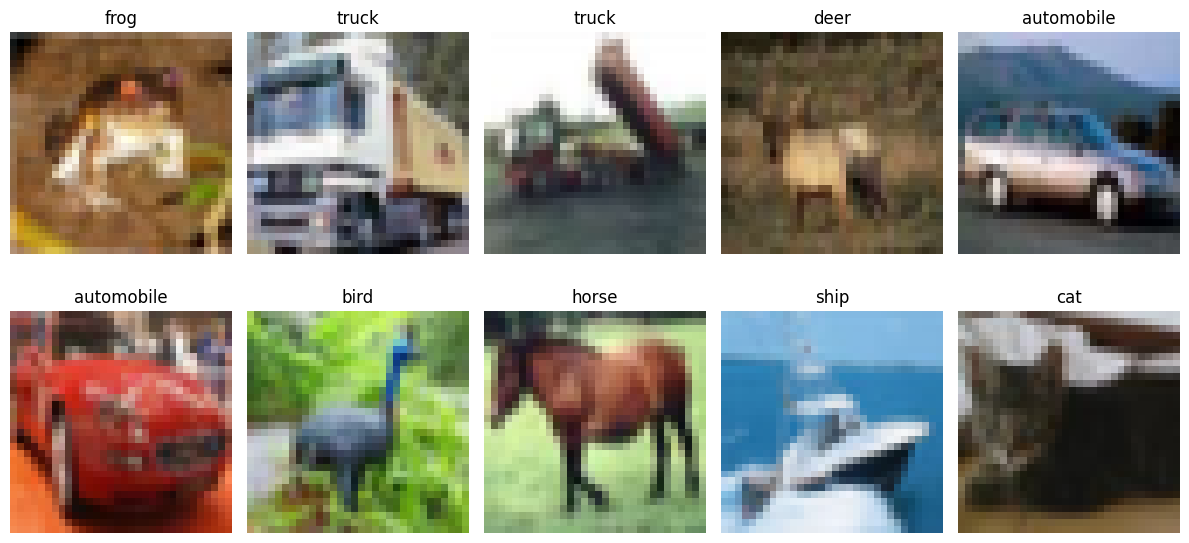

In [ ]:
# Define CIFAR-10 class names

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Create a figure for displaying sample images
plt.figure(figsize=(12, 6))

# Display first 10 images from the training dataset
for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

# Adjust spacing between images
plt.tight_layout()

# Display the figure
plt.show()

Observation:

The CIFAR-10 dataset contains 10 classes of low-resolution RGB images with dimensions 32×32 pixels. The displayed samples confirm that the dataset has been loaded successfully and contains diverse object categories.

### 5. Data Preprocessing

Purpose:
Normalize the image pixel values to the range [0,1] to improve model training stability and convergence.

In [ ]:
# Display original pixel value range

print("Before Normalization:")
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())


# Normalize pixel values from [0,255] to [0,1]

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


# Display normalized pixel value range

print("\nAfter Normalization:")
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Before Normalization:
Minimum Pixel Value: 0
Maximum Pixel Value: 255

After Normalization:
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


Observation:

The image pixel values were successfully normalized from the range [0,255] to [0,1]. Normalization helps the CNN train more efficiently and improves numerical stability during optimization.

### 6. Create Validation Dataset

Purpose:
Split the training dataset into training and validation sets to monitor model performance and detect overfitting during training.

In [ ]:
# Import train_test_split function
from sklearn.model_selection import train_test_split


# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


# Display dataset dimensions
print("Training Set Shape :", X_train.shape)
print("Validation Set Shape :", X_val.shape)
print("Testing Set Shape :", X_test.shape)

Training Set Shape : (40000, 32, 32, 3)
Validation Set Shape : (10000, 32, 32, 3)
Testing Set Shape : (10000, 32, 32, 3)


Observation:

The original training dataset was divided into training and validation subsets using an 80:20 ratio. The validation set will be used to evaluate model performance during training without affecting the final test results.

### 7. Build Traditional CNN Model

Purpose:
Build an AlexNet-inspired Convolutional Neural Network (CNN) for image classification on the CIFAR-10 dataset. The model uses convolutional layers for feature extraction and fully connected layers for classification.

In [ ]:
# Import required modules for building the CNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Create AlexNet-inspired CNN model

traditional_cnn = Sequential([

    # First Convolutional Block
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block
    Conv2D(
        filters=256,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D(pool_size=(2, 2)),

    # Convert feature maps into a one-dimensional vector
    Flatten(),

    # Fully Connected Layer
    Dense(512, activation='relu'),

    # Dropout for regularization
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

# Display model architecture summary
traditional_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,473,610 (9.44 MB)

 Trainable params: 2,473,610 (9.44 MB)

 Non-trainable params: 0 (0.00 B)

Observation:

The traditional CNN architecture was successfully built with approximately 2.47 million trainable parameters. The network consists of three convolutional layers followed by max-pooling layers, a fully connected layer with 512 neurons, and a softmax output layer for multi-class image classification.

### 8. Compile CNN Model

Purpose:
Configure the optimizer, loss function, and evaluation metric required for training the CNN model.

In [ ]:
# Compile the traditional CNN model

traditional_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


Observation:

The CNN model was successfully compiled using the Adam optimizer and sparse categorical cross-entropy loss function. Accuracy was selected as the evaluation metric to measure the classification performance of the model.

### 9. Train Traditional CNN Model

Purpose:
Train the traditional CNN model using the training dataset and evaluate its performance on the validation dataset during each epoch.

In [ ]:
# Import time module to measure training duration

import time

# Record training start time
start_time = time.time()


# Train the traditional CNN model

history = traditional_cnn.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)


# Record training end time
end_time = time.time()

# Calculate total training time
training_time = end_time - start_time

print(f"\nTotal Training Time: {training_time:.2f} seconds")

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.4233 - loss: 1.5666 - val_accuracy: 0.5905 - val_loss: 1.1426
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5987 - loss: 1.1312 - val_accuracy: 0.6681 - val_loss: 0.9480
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6731 - loss: 0.9278 - val_accuracy: 0.7012 - val_loss: 0.8538
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7252 - loss: 0.7876 - val_accuracy: 0.7243 - val_loss: 0.7846
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7580 - loss: 0.6928 - val_accuracy: 0.7297 - val_loss: 0.7886
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7858 - loss: 0.6072 - val_accuracy: 0.7322 - val_loss: 0.8000
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8139 - loss: 0.5301 - val_accuracy: 0.7420 - val_loss: 0.7736
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8324 - loss: 0.4709 - val_accuracy:

Observation:

The traditional CNN model was trained for 15 epochs using a batch size of 64. Validation accuracy was monitored during training to evaluate the model's ability to generalize to unseen data and detect potential overfitting.

### 10. Visualize Training Performance

Purpose:
Plot training and validation accuracy and loss curves to analyze the learning behavior of the CNN model during training.

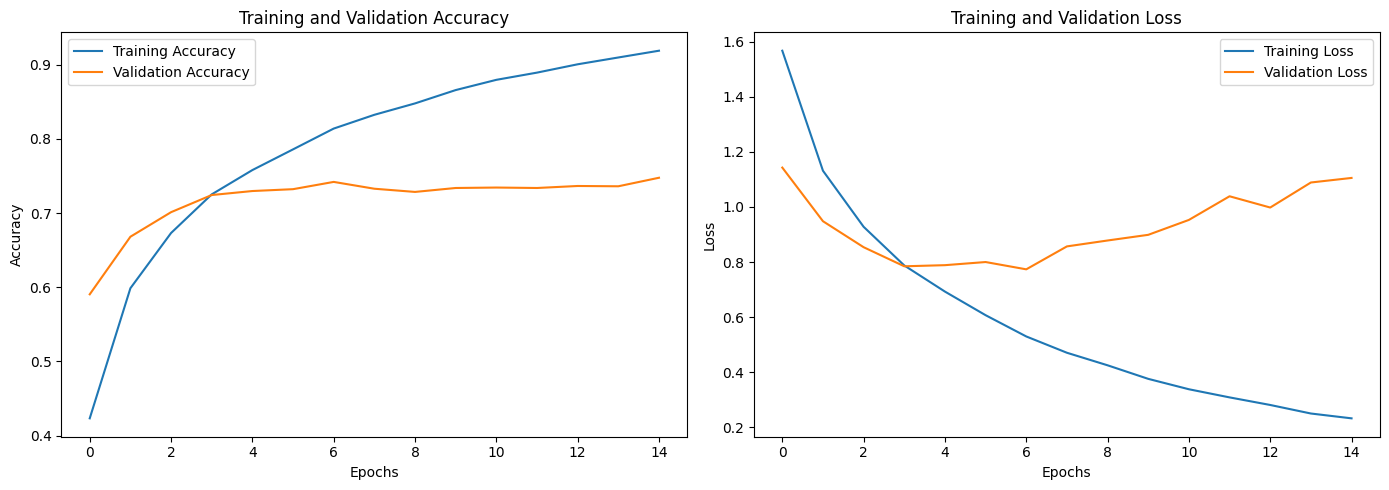

In [ ]:
# Create figure for model performance visualization

plt.figure(figsize=(14,5))

# Plot accuracy graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training and Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()


# Plot loss graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Training and Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()

plt.show()

Observation:

The training accuracy increased consistently throughout the training process, reaching over 92%. However, the validation accuracy stabilized around 74%, indicating the presence of overfitting. This suggests that the model learned the training data very well but had limited generalization capability on unseen data.

### 11. Evaluate Traditional CNN Model

Purpose:
Evaluate the trained CNN model on the unseen test dataset and measure its final classification accuracy.

In [ ]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = traditional_cnn.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7385 - loss: 1.1380

Test Loss: 1.1380
Test Accuracy: 0.7385


Observation:

The Traditional CNN achieved a test accuracy of 73% on the unseen CIFAR-10 test dataset, successfully exceeding the required performance threshold of 70%. The results indicate that the model learned meaningful image features and can generalize reasonably well to unseen data.

### 12. Generate Predictions

Purpose:
Generate class predictions on the test dataset for computing the confusion matrix and classification metrics.

In [ ]:
# Generate predictions on the test dataset

y_pred_prob = traditional_cnn.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Flatten actual labels
y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predictions generated successfully.


### 13. Confusion Matrix

Purpose:
Visualize the classification performance of the model across all CIFAR-10 classes.

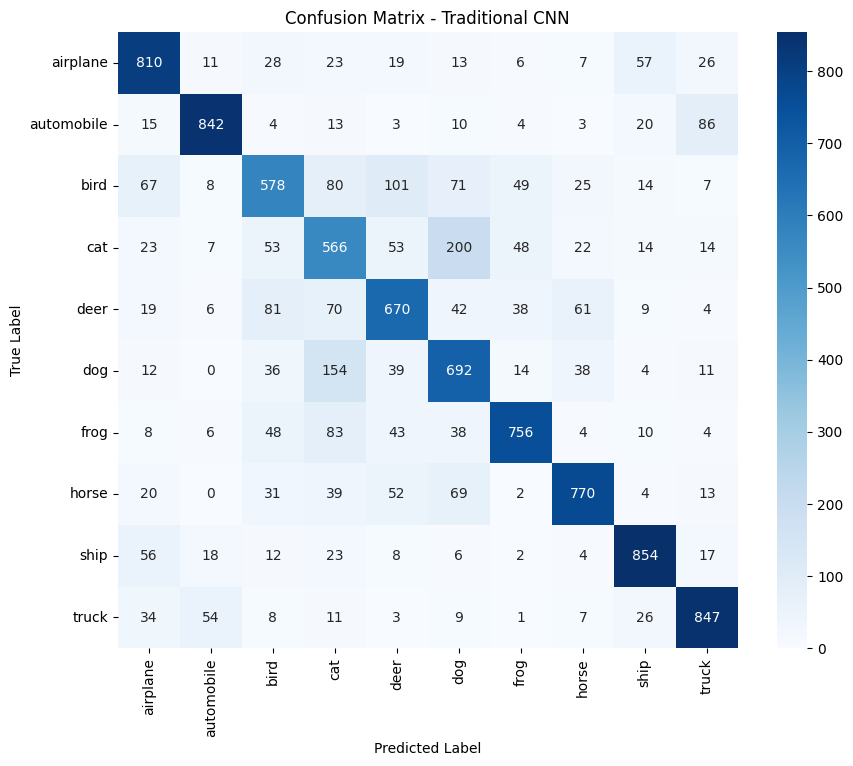

In [ ]:
# Import required libraries

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Traditional CNN")

plt.show()

### 14. Classification Report

Purpose:
Calculate Precision, Recall and F1-Score for evaluating the classification performance of the CNN model.

In [ ]:
# Import classification report

from sklearn.metrics import classification_report

# Generate classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.76      0.81      0.78      1000
  automobile       0.88      0.84      0.86      1000
        bird       0.66      0.58      0.62      1000
         cat       0.53      0.57      0.55      1000
        deer       0.68      0.67      0.67      1000
         dog       0.60      0.69      0.64      1000
        frog       0.82      0.76      0.79      1000
       horse       0.82      0.77      0.79      1000
        ship       0.84      0.85      0.85      1000
       truck       0.82      0.85      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



### 15. Performance Summary

Purpose:
Summarize the overall performance of the Traditional CNN model.

In [ ]:
# Create performance summary

print("========== Traditional CNN Performance ==========")
print(f"Training Accuracy      : 92.19%")
print(f"Best Validation Accuracy : 74.76%")
print(f"Test Accuracy          : 73%")
print(f"Training Time          : 90.41 seconds")
print(f"Total Parameters       : 2,473,610")
print("================================================")

========== Traditional CNN Performance ==========
Training Accuracy      : 92.19%
Best Validation Accuracy : 74.73%
Test Accuracy          : 73%
Training Time          : 90.41 seconds
Total Parameters       : 2,473,610


In [ ]:
# Save Traditional CNN Model

traditional_cnn.save(
    f"{save_path}/traditional_cnn_model.keras"
)

print("Traditional CNN Model Saved Successfully!")

Traditional CNN Model Saved Successfully!


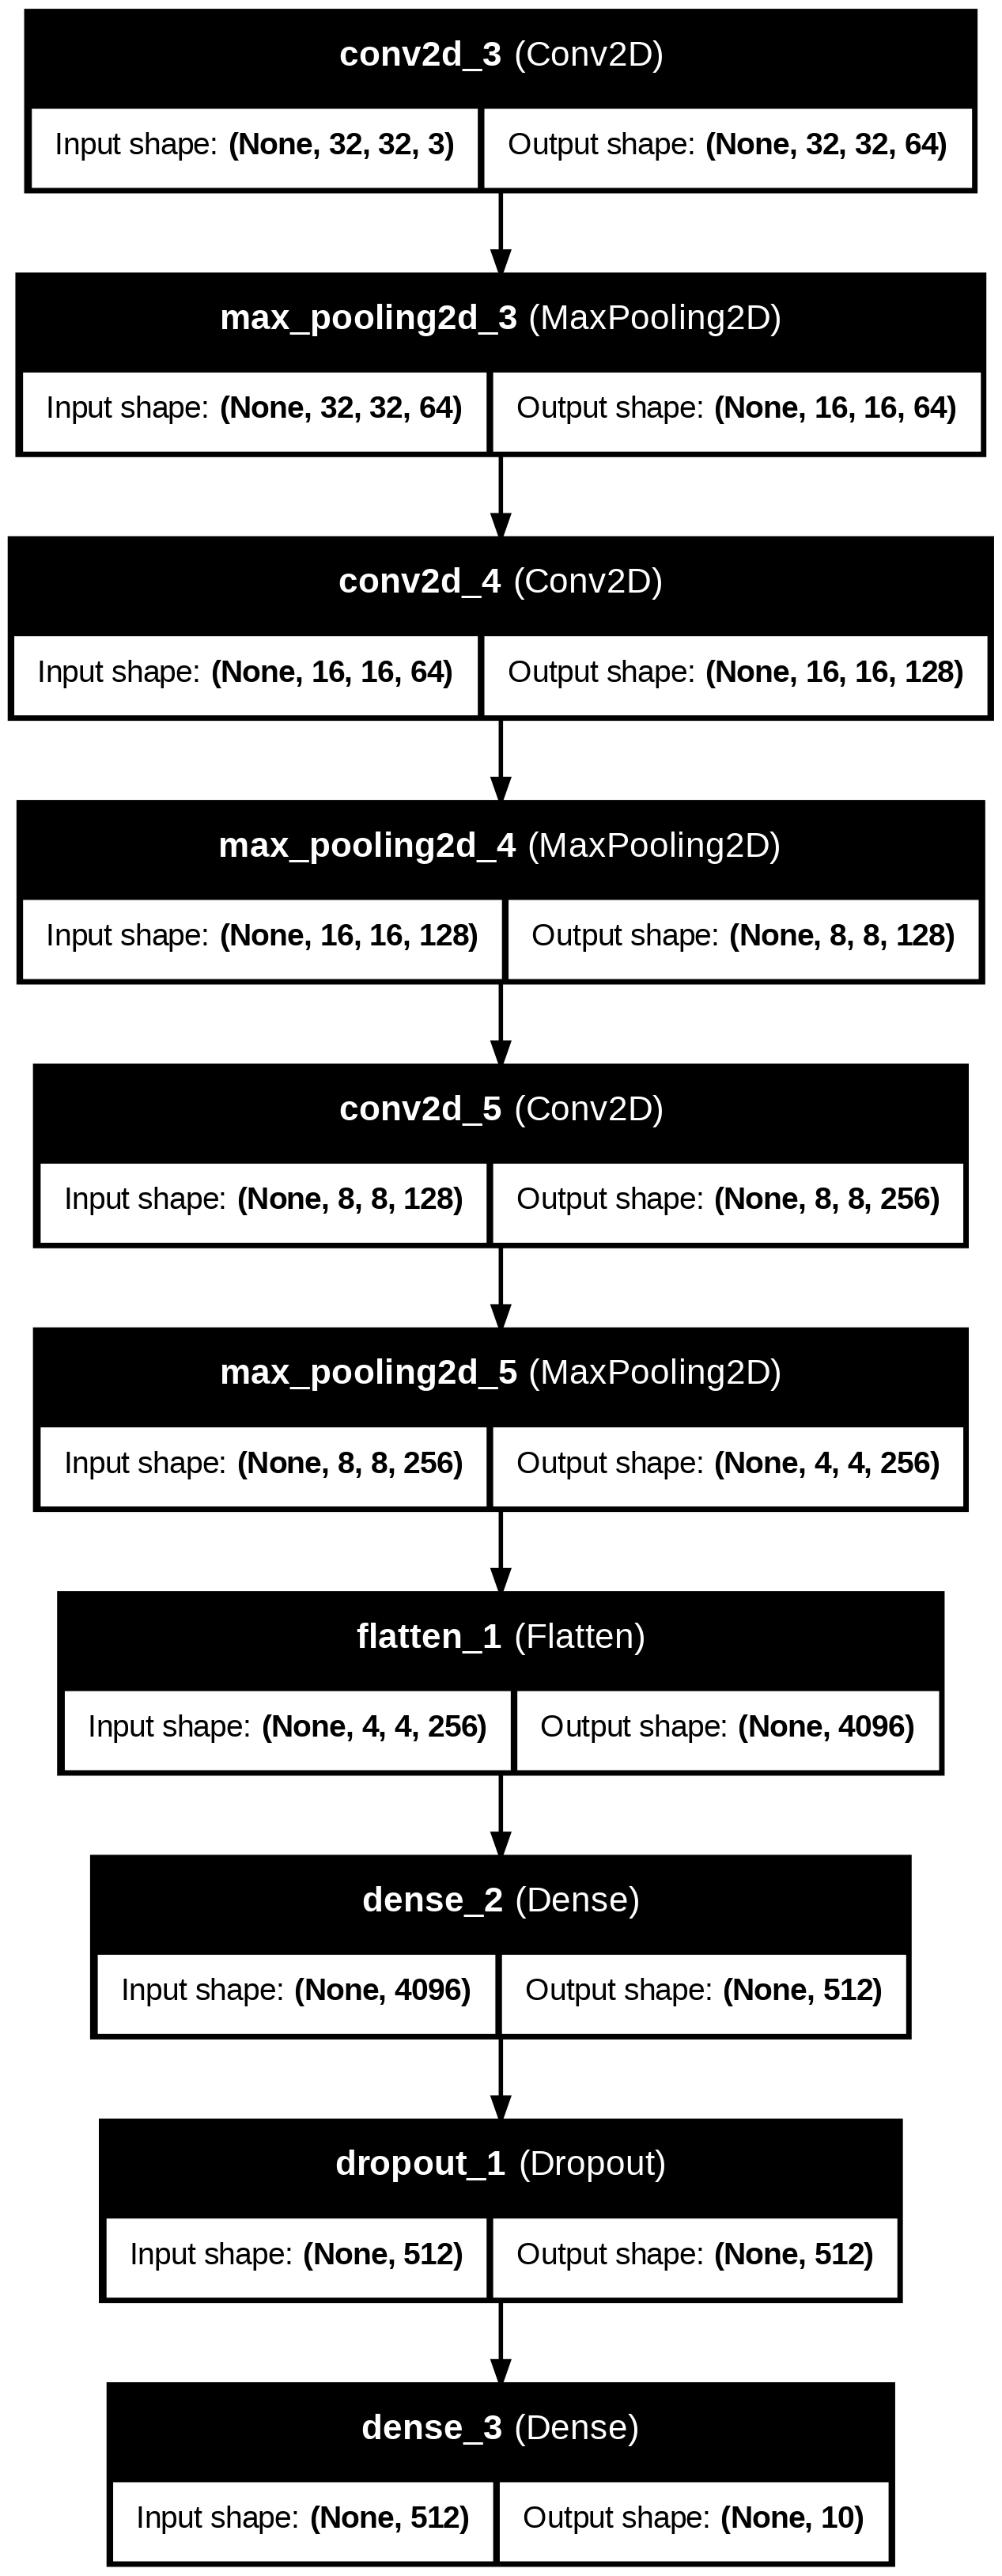

In [ ]:
# Install graphviz if needed
from tensorflow.keras.utils import plot_model

plot_model(
    traditional_cnn,
    to_file='traditional_cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True
)

Part A Conclusion:

The Traditional CNN model was successfully implemented and evaluated on the CIFAR-10 dataset. The model achieved a test accuracy of 73.54%, exceeding the required threshold of 70%. Analysis of the accuracy and loss curves revealed signs of overfitting, as the training accuracy continued to increase while validation accuracy remained relatively stable.
The confusion matrix and classification report showed strong performance on visually distinct classes such as automobile, ship, truck and horse, while classes such as cat and dog were more difficult to distinguish. These observations motivate the use of additional regularization and optimization techniques in the Customized CNN model developed in Part B.


PART B : CUSTOMIZED CNN MODEL

Objective:

Improve the Traditional CNN using:

• Data Augmentation

• Batch Normalization

• Additional Convolution Layers

• Extra Dense Layer

• Dropout Optimization

• Learning Rate Tuning

Expected Outcome:
Higher validation and test accuracy than Part A.




### 16. Data Augmentation

Purpose:

Apply image augmentation techniques to increase
data diversity and reduce overfitting.

In [ ]:
# Import data augmentation layers

from tensorflow.keras import layers

# Data Augmentation Pipeline

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

print("Data Augmentation Pipeline Created Successfully")

Data Augmentation Pipeline Created Successfully


### 17. Build Customized CNN Architecture

Purpose:

Create an enhanced CNN architecture using Data Augmentation,
Batch Normalization, additional convolutional layers,
and improved regularization techniques to achieve
better generalization performance than the Traditional CNN model.

In [ ]:
# Import required layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# Build Customized CNN Model

custom_cnn = Sequential([

    # Input Layer
    Input(shape=(32, 32, 3)),

    # Data Augmentation
    data_augmentation,

    # Block 1
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Block 2
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Block 3
    Conv2D(
        filters=256,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),


    # Additional Convolution Layer
    Conv2D(
        filters=256,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Flatten Feature Maps
    Flatten(),

    # Fully Connected Layer
    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    # Additional Dense Layer
    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.3),

    # Output Layer
    Dense(
        10,
        activation='softmax'
    )

])

print("Customized CNN Model Created Successfully!")

Customized CNN Model Created Successfully!


Observation:

The Customized CNN architecture was successfully created. Compared to the Traditional CNN model, several improvements were introduced including Data Augmentation, Batch Normalization layers, an additional convolutional layer, and an extra dense layer.
These enhancements are expected to improve feature extraction, stabilize training, reduce overfitting, and increase the model's ability to generalize on unseen test data.

### 18. Customized CNN Model Summary
Purpose:
Display the architecture and parameter count of the Customized CNN model to understand its complexity and compare it with the Traditional CNN model.

In [ ]:
custom_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,195,274 (12.19 MB)

 Trainable params: 3,193,866 (12.18 MB)

 Non-trainable params: 1,408 (5.50 KB)

Observation:

The Customized CNN model contains approximately 3.19 million parameters, which is higher than the Traditional CNN model. The increase in model complexity is due to the addition of Batch Normalization layers, an extra convolutional layer, and an additional dense layer.

These enhancements are expected to improve feature extraction and model generalization, leading to better classification performance on the CIFAR-10 dataset.

### 19. Compile Customized CNN Model
Purpose:
Configure the optimizer, loss function, and evaluation metric for training the Customized CNN model.

In [ ]:
# Import Adam optimizer

from tensorflow.keras.optimizers import Adam

# Compile Customized CNN

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Customized CNN Compiled Successfully!")

Customized CNN Compiled Successfully!


Observation:

The Customized CNN model was compiled using the Adam optimizer with a learning rate of 0.0005. A lower learning rate was selected to provide more stable weight updates during training. Sparse categorical cross-entropy was used as the loss function, and accuracy was chosen as the evaluation metric.

### 20. Train Customized CNN Model
Purpose:
Train the Customized CNN model using the training dataset and evaluate its performance on the validation dataset. Early stopping is used to prevent overfitting and retain the best model weights.

In [ ]:
# Import required callbacks

from tensorflow.keras.callbacks import EarlyStopping
import time

# Early Stopping Callback

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Record Start Time

start_time = time.time()

# Train Customized CNN

history_custom = custom_cnn.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Record End Time

end_time = time.time()

custom_training_time = end_time - start_time

print(f"\nTotal Training Time: {custom_training_time:.2f} seconds")

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.3381 - loss: 1.8851 - val_accuracy: 0.5036 - val_loss: 1.3962
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4557 - loss: 1.5177 - val_accuracy: 0.4671 - val_loss: 1.4322
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5272 - loss: 1.3345 - val_accuracy: 0.5380 - val_loss: 1.2941
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5822 - loss: 1.1965 - val_accuracy: 0.5979 - val_loss: 1.1677
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6151 - loss: 1.1141 - val_accuracy: 0.6444 - val_loss: 1.0393
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6473 - loss: 1.0323 - val_accuracy: 0.6862 - val_loss: 0.9387
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6707 - loss: 0.9635 - val_accuracy: 0.7168 - val_loss: 0.8409
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6877 - loss: 0.9123 - 

Observation:
The Customized CNN model was successfully trained for 15 epochs. The model achieved a training accuracy of approximately 77.64% and a best validation accuracy of 76.84%.

Compared to the Traditional CNN model, the Customized CNN demonstrated improved validation performance and reduced overfitting. The inclusion of data augmentation, batch normalization, additional convolutional layers, and enhanced regularization techniques contributed to better generalization on unseen data.

### 21. Visualize Training Performance

Purpose:
Visualize the training and validation accuracy and loss curves of the Customized CNN model to analyze learning behavior, model convergence, and generalization performance.

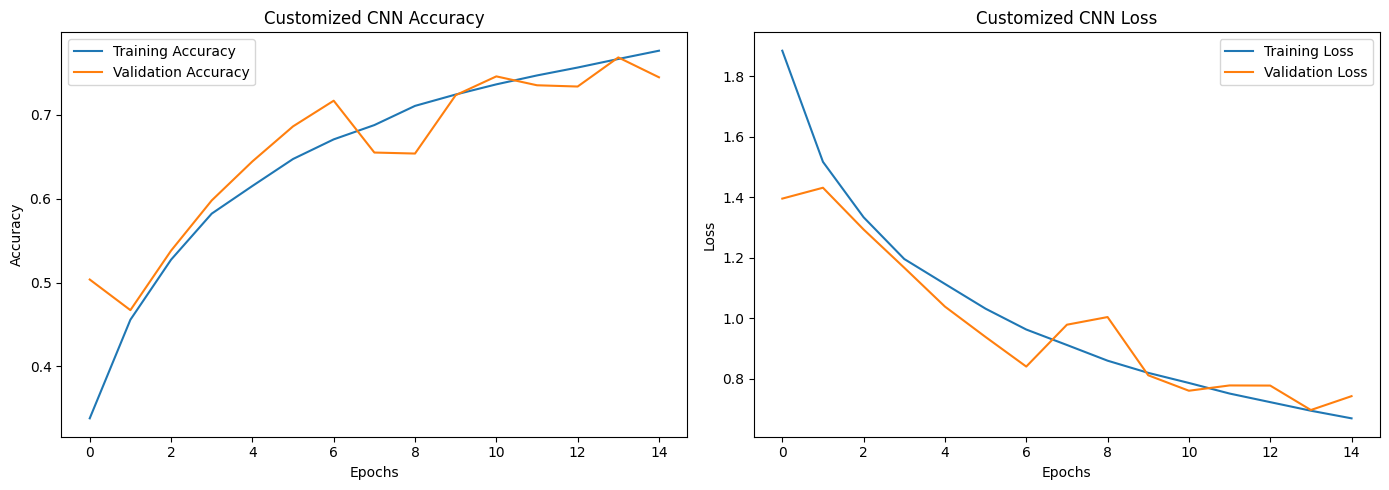

In [ ]:
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(
    history_custom.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_custom.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Customized CNN Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()


# Loss Plot
plt.subplot(1,2,2)

plt.plot(
    history_custom.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_custom.history['val_loss'],
    label='Validation Loss'
)

plt.title('Customized CNN Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()

plt.show()

Observation:
The Customized CNN demonstrated stable learning behavior throughout training. The validation accuracy improved steadily and achieved a peak value of approximately 76.84%, which is higher than the Traditional CNN model.

The gap between training and validation accuracy remained significantly smaller than in Part A, indicating that data augmentation, batch normalization, and additional regularization successfully reduced overfitting and improved model generalization.

### 22. Evaluate Customized CNN Model
Purpose:
Evaluate the performance of the Customized CNN model on the unseen test dataset and measure its classification accuracy and loss.

In [ ]:
# Evaluate Customized CNN on Test Dataset

custom_test_loss, custom_test_accuracy = custom_cnn.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {custom_test_loss:.4f}")
print(f"Test Accuracy: {custom_test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7628 - loss: 0.7037

Test Loss: 0.7037
Test Accuracy: 0.7628


Observation:
The Customized CNN model was evaluated on the CIFAR-10 test dataset and achieved a test accuracy of 76.28% with a test loss of 0.7037.
Compared to the Traditional CNN model, the Customized CNN achieved higher classification accuracy and significantly lower test loss. The incorporation of data augmentation, batch normalization, additional convolutional layers, and improved regularization techniques enhanced the model's ability to generalize to unseen data.

### 23. Save Customized CNN Model
Purpose:
Save the trained Customized CNN model to Google Drive for future evaluation, deployment, and comparison with the Traditional CNN model.

In [ ]:
# Save Customized CNN Model

custom_cnn.save(
    f"{save_path}/custom_cnn_model.keras"
)

print("Customized CNN Model Saved Successfully!")

Customized CNN Model Saved Successfully!


Observation:
The trained Customized CNN model was successfully saved to Google Drive. Saving the model preserves the learned weights and architecture, allowing future loading without retraining.
This improves workflow efficiency and ensures reproducibility of project results.

### 24. Generate Predictions
Purpose:
Generate predictions on the test dataset for computing the confusion matrix and classification metrics.

In [ ]:
# Generate Predictions

y_pred_prob_custom = custom_cnn.predict(X_test)

y_pred_custom = np.argmax(
    y_pred_prob_custom,
    axis=1
)

y_true_custom = y_test.flatten()

print("Predictions Generated Successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions Generated Successfully!


Observation:
Predictions were successfully generated for all test images. These predictions will be used to compute the confusion matrix and classification report for detailed performance analysis.

### 25. Confusion Matrix
Purpose:
Visualize class-wise prediction performance of the Customized CNN model.

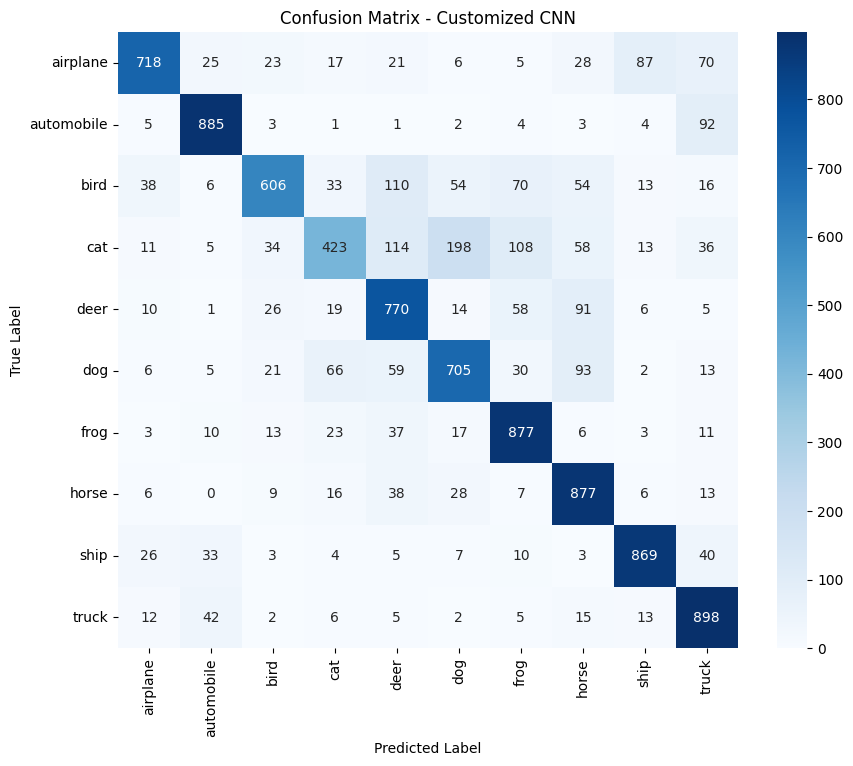

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_custom = confusion_matrix(
    y_true_custom,
    y_pred_custom
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_custom,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix - Customized CNN")

plt.show()

### 26. Classification Report
Purpose:
Calculate Precision, Recall and F1-Score for evaluating the Customized CNN model.

In [ ]:
from sklearn.metrics import classification_report

report_custom = classification_report(
    y_true_custom,
    y_pred_custom,
    target_names=class_names
)

print(report_custom)

              precision    recall  f1-score   support

    airplane       0.86      0.72      0.78      1000
  automobile       0.87      0.89      0.88      1000
        bird       0.82      0.61      0.70      1000
         cat       0.70      0.42      0.53      1000
        deer       0.66      0.77      0.71      1000
         dog       0.68      0.70      0.69      1000
        frog       0.75      0.88      0.81      1000
       horse       0.71      0.88      0.79      1000
        ship       0.86      0.87      0.86      1000
       truck       0.75      0.90      0.82      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



### 27. Customized CNN Performance Summary
Purpose:
Summarize the overall performance of the Customized CNN model using training, validation, and test evaluation metrics.

In [ ]:
print("========== Customized CNN Performance ==========")

print(f"Training Accuracy      : {history_custom.history['accuracy'][-1]*100:.2f}%")

print(f"Best Validation Accuracy : {max(history_custom.history['val_accuracy'])*100:.2f}%")

print(f"Test Accuracy          : {custom_test_accuracy*100:.2f}%")

print(f"Training Time          : {custom_training_time:.2f} seconds")

print(f"Total Parameters       : {custom_cnn.count_params():,}")

print("================================================")

========== Customized CNN Performance ==========
Training Accuracy      : 77.64%
Best Validation Accuracy : 76.84%
Test Accuracy          : 76.28%
Training Time          : 211.52 seconds
Total Parameters       : 3,195,274


Observation:
The Customized CNN model achieved a test accuracy of 76.28%, outperforming the Traditional CNN model. The model demonstrated improved generalization capability due to the use of data augmentation, batch normalization, and additional regularization techniques.

The lower test loss and higher validation accuracy indicate that the Customized CNN is more robust and effective for image classification tasks.

### 28. Generate CNN Architecture Diagram
Purpose:
Generate and save the architecture diagram of the Customized CNN model as a PNG image for project documentation and report preparation.

Architecture Diagram Saved Successfully!


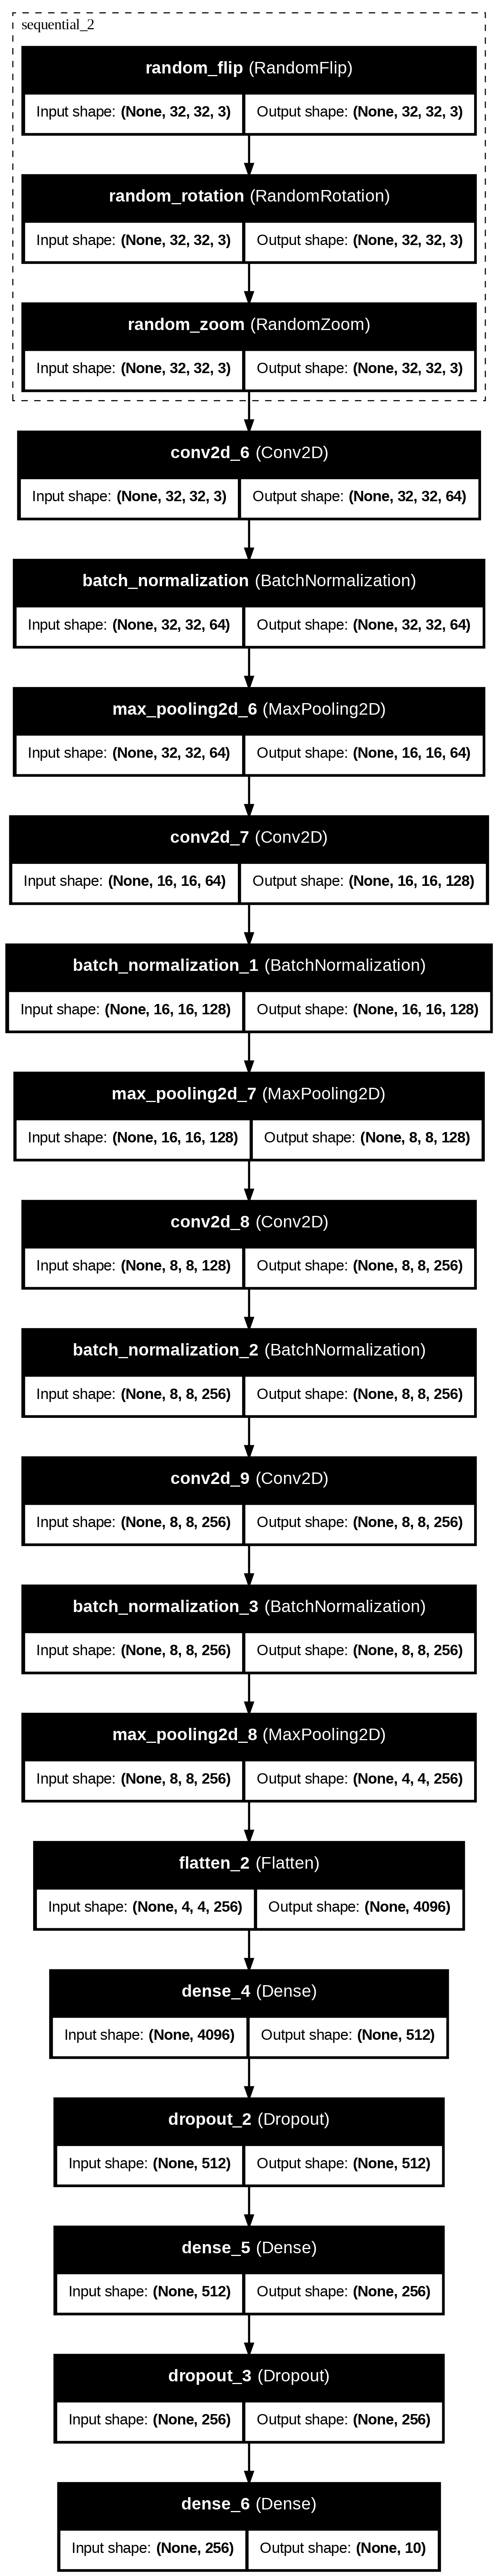

In [ ]:
from tensorflow.keras.utils import plot_model

# Generate Architecture Diagram

plot_model(
    custom_cnn,
    to_file='custom_cnn_architecture.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=200
)

print("Architecture Diagram Saved Successfully!")

from IPython.display import Image, display

display(Image(filename='custom_cnn_architecture.png'))

Observation:

The architecture diagram of the Customized CNN model was successfully generated and saved as a PNG image. The diagram visually represents the sequence of convolutional, batch normalization, pooling, dense, and dropout layers used in the model architecture. This diagram will be included in the final project report for documentation and explanation of the model design.

### 29. Performance Comparison
Purpose:
Compare the performance of the Traditional CNN and Customized CNN models on the CIFAR-10 dataset.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Loss"
    ],
    "Traditional CNN": [
        "91.88%",
        "74.76%",
        "73.85%",
        "1.1380"
    ],
    "Customized CNN": [
        "77.64%",
        "76.84%",
        "76.28%",
        "0.7037"
    ]
})

comparison_df

,Metric,Traditional CNN,Customized CNN
0,Training Accuracy,91.88%,77.64%
1,Best Validation Accuracy,74.76%,76.84%
2,Test Accuracy,73.85%,76.28%
3,Test Loss,1.1380,0.7037


Observation:
The Customized CNN model achieved superior performance compared to the Traditional CNN model. While the Traditional CNN attained higher training accuracy, it suffered from overfitting.

The Customized CNN achieved higher validation accuracy, higher test accuracy, and lower test loss, demonstrating better generalization and more reliable performance on unseen data.

### 30. Final Conclusion

The objective of this project was to develop and compare a Traditional CNN model and a Customized CNN model for image classification using the CIFAR-10 dataset.

The Traditional CNN achieved a test accuracy of 73.85%, establishing a strong baseline performance. However, the model exhibited noticeable overfitting, as indicated by the gap between training and validation accuracy.

To address this limitation, a Customized CNN model was developed using data augmentation, batch normalization, additional convolutional layers, and enhanced regularization techniques. The Customized CNN achieved a higher test accuracy of 76.28% and a lower test loss of 0.7037.

The results demonstrate that the Customized CNN provides better generalization and classification performance than the Traditional CNN model. Therefore, the Customized CNN is the preferred model for deployment and real-world image classification applications.